/tmp/ipykernel_1018/4277871450.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  home_stats = df_final.groupby('home_team').apply(lambda x: pd.Series({
/tmp/ipykernel_1018/4277871450.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  away_stats = df_final.groupby('away_team').apply(lambda x: pd.Series({



--- 2026 WORLD CUP WIN PROBABILITIES ---
Spain           | 10.1%
Portugal        | 9.8%
France          | 9.5%
Argentina       | 9.1%
Brazil          | 9.0%
Morocco         | 5.3%
England         | 5.2%
Belgium         | 5.2%
Netherlands     | 4.5%
Germany         | 3.2%


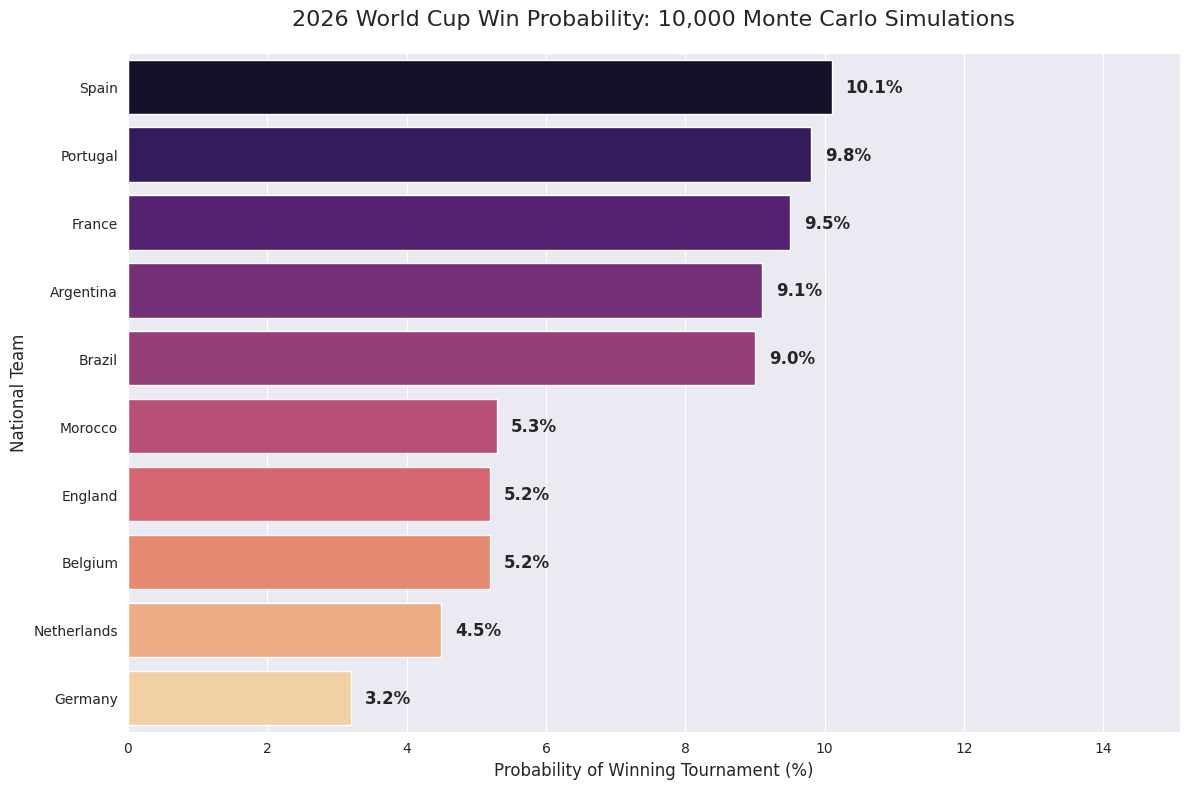


Success! Your visual has been saved as 'world_cup_prediction.png' in the files tab.


In [83]:
import pandas as pd
import numpy as np
from collections import Counter

# LOAD & CLEAN DATA
df = pd.read_csv('results.csv')
df['date'] = pd.to_datetime(df['date'])
modern_df = df[df['date'] >= '2015-01-01'].copy()

# NORMALIZE NAMES
modern_df['home_team'] = modern_df['home_team'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
modern_df['away_team'] = modern_df['away_team'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# 2026 WC GROUPS
groups = {
    'Group A': ['Mexico', 'South Africa', 'South Korea', 'Czech Republic'],
    'Group B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'Group C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'Group D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'Group E': ['Germany', 'Curacao', 'Ivory Coast', 'Ecuador'],
    'Group F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'Group G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'Group H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'],
    'Group I': ['France', 'Senegal', 'Iraq', 'Norway'],
    'Group J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'Group K': ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia'],
    'Group L': ['England', 'Croatia', 'Ghana', 'Panama']
}
all_wc_teams = [team for sublist in groups.values() for team in sublist]

# CALCULATE STRENGTHS WITH TOURNAMENT & TIME WEIGHTS
df_final = modern_df[(modern_df['home_team'].isin(all_wc_teams)) & (modern_df['away_team'].isin(all_wc_teams))].copy()
avg_home, avg_away = df_final['home_score'].mean(), df_final['away_score'].mean()

df_final['days_since'] = (df_final['date'].max() - df_final['date']).dt.days
df_final['weight'] = np.exp(-0.0005 * df_final['days_since'])

home_stats = df_final.groupby('home_team').apply(lambda x: pd.Series({
    'att': (x['home_score'] * x['weight']).sum() / x['weight'].sum(),
    'def': (x['away_score'] * x['weight']).sum() / x['weight'].sum()
}))
away_stats = df_final.groupby('away_team').apply(lambda x: pd.Series({
    'att': (x['away_score'] * x['weight']).sum() / x['weight'].sum(),
    'def': (x['home_score'] * x['weight']).sum() / x['weight'].sum()
}))

team_stats = pd.concat([home_stats, away_stats], axis=1).fillna(0)
team_stats.columns = ['h_att', 'h_def', 'a_att', 'a_def']
team_stats['att_strength'] = (team_stats['h_att'] + team_stats['a_att']) / (avg_home + avg_away)
team_stats['def_strength'] = (team_stats['h_def'] + team_stats['a_def']) / (avg_home + avg_away)

# APPLY FIFA RANKING ANCHOR (LATEST ONE, IN THIS CASE APRIL 2026)
fifa_pts = {'France': 1877, 'Spain': 1876, 'Argentina': 1874, 'England': 1825, 'Portugal': 1763, 'Brazil': 1761, 'Netherlands': 1757, 'Morocco': 1755, 'Belgium': 1734, 'Germany': 1730}
team_stats['fifa_mult'] = team_stats.index.map(lambda x: fifa_pts.get(x, 1400) / 1877)
team_stats['final_att'] = (team_stats['att_strength'] * 0.5) + (team_stats['fifa_mult'] * 0.5)
team_stats['final_def'] = (team_stats['def_strength'] * 0.5) + ((2 - team_stats['fifa_mult']) * 0.5)

# SIMULATION FUNCTIONS
def get_match_score(t1, t2):
    t1_b = 1.10 if t1 in ['United States', 'Mexico', 'Canada'] else 1.0
    lh = team_stats.at[t1, 'final_att'] * team_stats.at[t2, 'final_def'] * avg_home * t1_b
    la = team_stats.at[t2, 'final_att'] * team_stats.at[t1, 'final_def'] * avg_away
    return np.random.poisson(lh), np.random.poisson(la)

def simulate_tournament():
    knockout_teams = []
    third_place = []
    for name, teams in groups.items():
        points = {t: 0 for t in teams}
        for i in range(len(teams)):
            for j in range(i+1, len(teams)):
                h, a = get_match_score(teams[i], teams[j])
                if h > a: points[teams[i]] += 3
                elif a > h: points[teams[j]] += 3
                else: points[teams[i]] += 1; points[teams[j]] += 1
        res = sorted(points.items(), key=lambda x: x[1], reverse=True)
        knockout_teams += [res[0][0], res[1][0]]
        third_place.append(res[2])

    knockout_teams += [t[0] for t in sorted(third_place, key=lambda x: x[1], reverse=True)[:8]]
    np.random.shuffle(knockout_teams)

    curr = knockout_teams
    while len(curr) > 1:
        next_r = []
        for i in range(0, len(curr), 2):
            h, a = 0, 0
            while h == a: h, a = get_match_score(curr[i], curr[i+1])
            next_r.append(curr[i] if h > a else curr[i+1])
        curr = next_r
    return curr[0]

# RUN SIMS (ANY NUMBER OF SIMS, JUST CHANGE NUMBER BELOW)
num_sims = 10000
winners = [simulate_tournament() for _ in range(num_sims)]
final_results = Counter(winners)

print("\n--- 2026 WORLD CUP WIN PROBABILITIES ---")
for team, count in final_results.most_common(10):
    print(f"{team:15} | {count/num_sims:.1%}")

import matplotlib.pyplot as plt
import seaborn as sns

# SHOW DATA
top_10 = final_results.most_common(10)
teams, counts = zip(*top_10)
probs = [round((c / num_sims) * 100, 1) for c in counts]

# PLOT
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid") # Professional look
ax = sns.barplot(x=probs, y=teams, hue=teams, palette="magma", legend=False)
for i, p in enumerate(probs):
    ax.text(p + 0.2, i, f'{p}%', va='center', fontweight='bold', fontsize=12)

plt.title('2026 World Cup Win Probability: 10,000 Monte Carlo Simulations', fontsize=16, pad=20)
plt.xlabel('Probability of Winning Tournament (%)', fontsize=12)
plt.ylabel('National Team', fontsize=12)
plt.xlim(0, max(probs) + 5) # Give space for the labels
plt.tight_layout()
plt.savefig('world_cup_prediction.png', dpi=300)
plt.show()

print("\nSuccess! Your visual has been saved as 'world_cup_prediction.png' in the files tab.")
